# Task 2: Exploratory Data Analysis

## Objective
Perform comprehensive exploratory data analysis on Ethiopia's Financial Inclusion dataset to uncover trends, patterns, and insights across Access, Usage, and Infrastructure dimensions.

### Deliverables:
- Dataset overview and summary statistics
- Access trends analysis (account ownership, growth rates, gender gaps)
- Usage patterns analysis (mobile money, digital payments)
- Infrastructure and enablers analysis
- **Event Timeline Visualization and Overlays**
- **Correlation Analysis**
- **Data Limitations Section**
- **Key Insights Documentation**

In [12]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Add src to path
sys.path.append('../src')
try:
    from utils import save_fig, save_summary, calculate_growth_rate, calculate_gender_gap, create_correlation_matrix
except ImportError:
    print("Warning: utils.py not found or failed to import. Helper functions unavailable.")

# Set style
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)

# Define paths
DATA_PATH = '../data/raw/ethiopia_fi_unified_data.csv'
REPORTDATA_PATH = '../data/reportdata'
FIGURES_PATH = os.path.join(REPORTDATA_PATH, 'figures')
SUMMARIES_PATH = os.path.join(REPORTDATA_PATH, 'summaries')

# Create directories if they don't exist
os.makedirs(FIGURES_PATH, exist_ok=True)
os.makedirs(SUMMARIES_PATH, exist_ok=True)

## 1. Dataset Overview

In [13]:
# Load dataset
try:
    df = pd.read_csv(DATA_PATH)
    
    # Parse dates
    df['observation_date'] = pd.to_datetime(df['observation_date'], errors='coerce')
    df['year'] = df['observation_date'].dt.year

    print(f"Dataset shape: {df.shape}")
    print(f"Date range: {df['observation_date'].min()} to {df['observation_date'].max()}")
    print(f"\nRecord types:")
    print(df['record_type'].value_counts())
    print(f"\nPillars:")
    print(df['pillar'].value_counts())
except FileNotFoundError:
    print(f"Error: Data file not found at {DATA_PATH}")
    df = pd.DataFrame() # Empty frame to prevent downstream crashes

Dataset shape: (43, 35)
Date range: 2014-12-31 00:00:00 to 2030-12-31 00:00:00

Record types:
record_type
observation    30
event          10
target          3
Name: count, dtype: int64

Pillars:
pillar
ACCESS           16
USAGE            11
GENDER            5
AFFORDABILITY     1
Name: count, dtype: int64


In [14]:
# Summary statistics for numeric indicators
if not df.empty:
    observations = df[df['record_type'] == 'observation'].copy()

    summary_stats = observations.groupby('indicator')['value_numeric'].agg([
        'count', 'mean', 'std', 'min', 'max'
    ]).round(2)

    print("Summary Statistics by Indicator:")
    print(summary_stats)

    save_summary(summary_stats.reset_index(), 'dataset_overview.csv')
else:
    print("No data loaded, skipping summary statistics.")

Summary Statistics by Indicator:
                                   count          mean          std  \
indicator                                                             
4G Population Coverage                 2  5.415000e+01        23.55   
ATM Transaction Count                  1  1.193000e+08          NaN   
ATM Transaction Value                  1  1.561000e+11          NaN   
Account Ownership Gender Gap           2  1.900000e+01         1.41   
Account Ownership Rate                 6  4.067000e+01        12.13   
Data Affordability Index               1  2.000000e+00          NaN   
Fayda Digital ID Enrollment            3  1.166667e+07   3511884.58   
Female Mobile Money Account Share      1  1.400000e+01          NaN   
M-Pesa 90-Day Active Users             1  7.100000e+06          NaN   
M-Pesa Registered Users                1  1.080000e+07          NaN   
Mobile Money Account Rate              2  7.070000e+00         3.36   
Mobile Money Activity Rate             1  6.

## 2. Access Analysis

Analyzing account ownership trends, growth rates, and gender gaps.

Account Ownership Growth:
   year  value_numeric  growth_rate
0  2014           22.0          NaN
1  2017           35.0    59.090909
2  2021           46.0    31.428571
3  2024           49.0     6.521739
✓ Saved: 03_access_trends.png


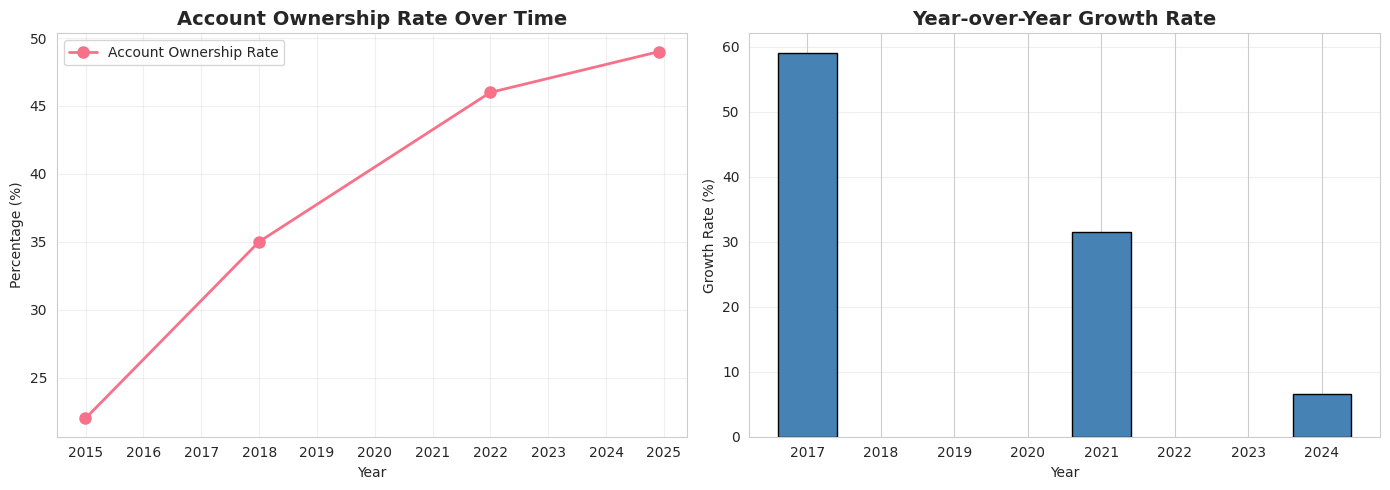

In [15]:
if not df.empty:
    # Account Ownership Rate over time
    acc_ownership = observations[observations['indicator_code'] == 'ACC_OWNERSHIP'].copy()
    acc_ownership = acc_ownership[acc_ownership['gender'] == 'all']  # Overall rate
    acc_ownership = acc_ownership.sort_values('observation_date')

    # Calculate growth rates
    try:
        growth_df = calculate_growth_rate(observations, 'ACC_OWNERSHIP')
        print("Account Ownership Growth:")
        print(growth_df)
    except Exception as e:
        print(f"Error calculating growth: {e}")
        growth_df = pd.DataFrame()

    # Visualize
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Trend line
    ax1.plot(acc_ownership['observation_date'], acc_ownership['value_numeric'], 
             marker='o', linewidth=2, markersize=8, label='Account Ownership Rate')
    ax1.set_title('Account Ownership Rate Over Time', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Percentage (%)')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Growth rates
    if not growth_df.empty:
        ax2.bar(growth_df['year'], growth_df['growth_rate'], color='steelblue', edgecolor='black')
        ax2.set_title('Year-over-Year Growth Rate', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Year')
        ax2.set_ylabel('Growth Rate (%)')
        ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    save_fig('03_access_trends')
    plt.show()

Gender Gap in Account Ownership:
gender  year   all  female  male   gap    gap_pct
0       2014  22.0     NaN   NaN   NaN        NaN
1       2017  35.0     NaN   NaN   NaN        NaN
2       2021  46.0    36.0  56.0  20.0  55.555556
3       2024  49.0     NaN   NaN   NaN        NaN
✓ Saved: access_summary.csv
✓ Saved: 04_gender_gap.png


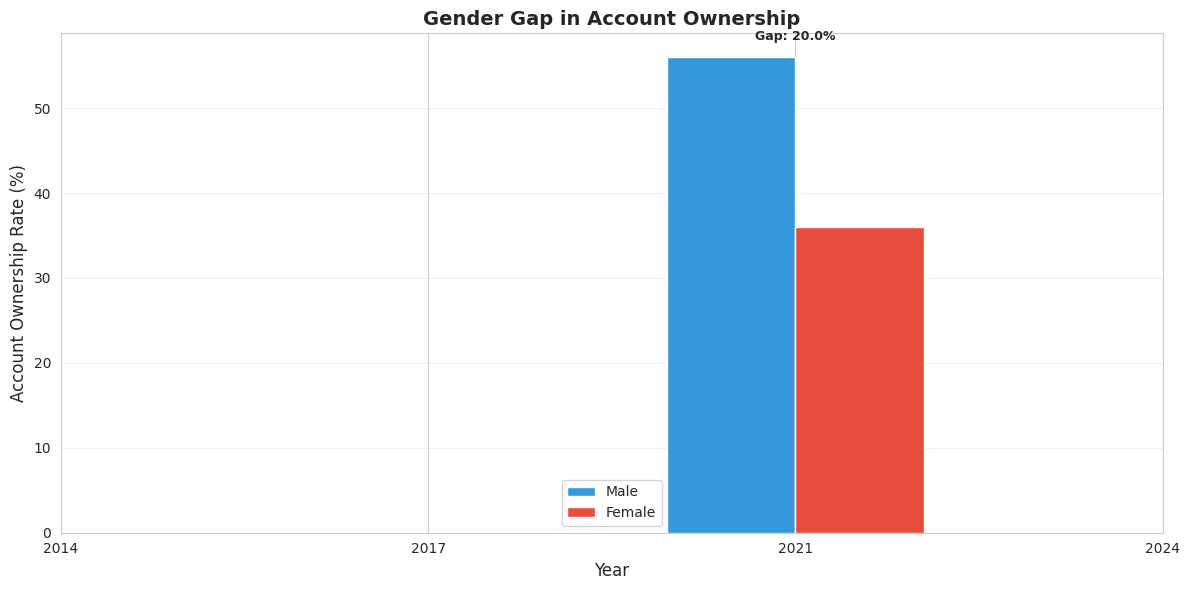

In [16]:
if not df.empty:
    # Gender gap analysis
    try:
        gender_gap = calculate_gender_gap(observations, 'ACC_OWNERSHIP')
        print("Gender Gap in Account Ownership:")
        print(gender_gap)
        save_summary(gender_gap, 'access_summary.csv')
    except Exception as e:
        print(f"Error calculating gender gap: {e}")
        gender_gap = pd.DataFrame()

    # Visualize gender gap
    if not gender_gap.empty:
        fig, ax = plt.subplots(figsize=(12, 6))

        x = np.arange(len(gender_gap))
        width = 0.35

        if 'male' in gender_gap.columns and 'female' in gender_gap.columns:
            ax.bar(x - width/2, gender_gap['male'], width, label='Male', color='#3498db')
            ax.bar(x + width/2, gender_gap['female'], width, label='Female', color='#e74c3c')
            
            # Add gap annotation
            for i, row in gender_gap.iterrows():
                if pd.notna(row.get('gap')):
                    ax.text(i, max(row.get('male', 0), row.get('female', 0)) + 2, 
                           f"Gap: {row['gap']:.1f}%", 
                           ha='center', fontsize=9, fontweight='bold')

        ax.set_xlabel('Year', fontsize=12)
        ax.set_ylabel('Account Ownership Rate (%)', fontsize=12)
        ax.set_title('Gender Gap in Account Ownership', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(gender_gap['year'])
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')

        plt.tight_layout()
        save_fig('04_gender_gap')
        plt.show()

## 3. Usage Analysis

Analyzing mobile money and digital payment transaction trends.

✓ Saved: 05_usage_trends.png


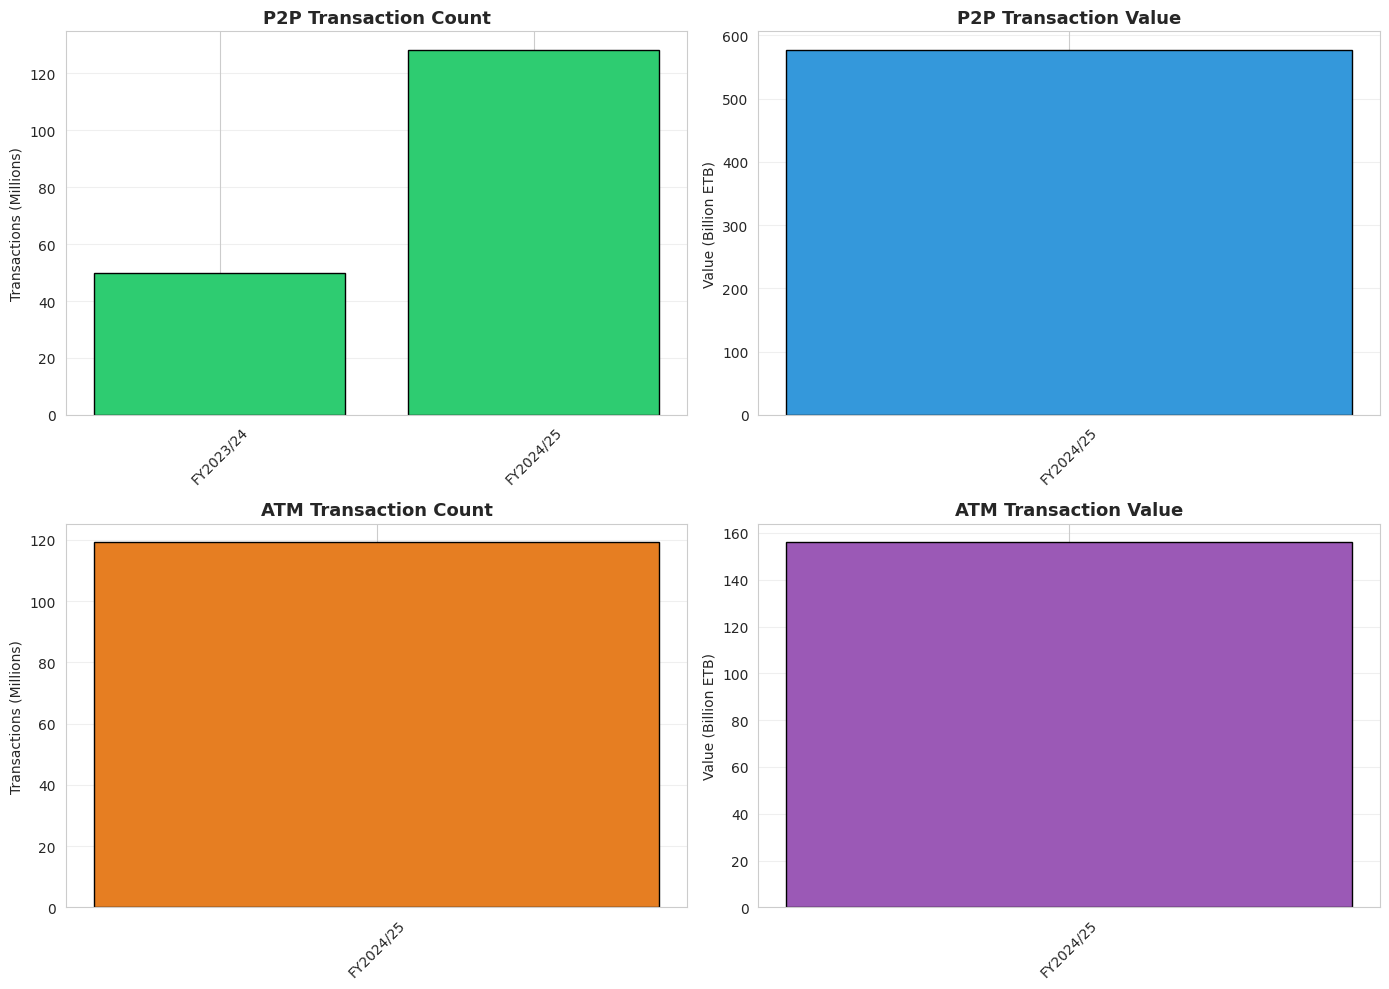

✓ Saved: usage_summary.csv


In [17]:
if not df.empty:
    # P2P Transaction analysis
    p2p_count = observations[observations['indicator_code'] == 'USG_P2P_COUNT'].copy()
    p2p_value = observations[observations['indicator_code'] == 'USG_P2P_VALUE'].copy()

    # ATM transactions
    atm_count = observations[observations['indicator_code'] == 'USG_ATM_COUNT'].copy()
    atm_value = observations[observations['indicator_code'] == 'USG_ATM_VALUE'].copy()

    # Visualize usage trends
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

    # P2P Count
    if len(p2p_count) > 0:
        ax1.bar(range(len(p2p_count)), p2p_count['value_numeric']/1e6, color='#2ecc71', edgecolor='black')
        ax1.set_title('P2P Transaction Count', fontsize=13, fontweight='bold')
        ax1.set_ylabel('Transactions (Millions)')
        ax1.set_xticks(range(len(p2p_count)))
        ax1.set_xticklabels(p2p_count['fiscal_year'], rotation=45)
        ax1.grid(True, alpha=0.3, axis='y')

    # P2P Value
    if len(p2p_value) > 0:
        ax2.bar(range(len(p2p_value)), p2p_value['value_numeric']/1e9, color='#3498db', edgecolor='black')
        ax2.set_title('P2P Transaction Value', fontsize=13, fontweight='bold')
        ax2.set_ylabel('Value (Billion ETB)')
        ax2.set_xticks(range(len(p2p_value)))
        ax2.set_xticklabels(p2p_value['fiscal_year'], rotation=45)
        ax2.grid(True, alpha=0.3, axis='y')

    # ATM Count
    if len(atm_count) > 0:
        ax3.bar(range(len(atm_count)), atm_count['value_numeric']/1e6, color='#e67e22', edgecolor='black')
        ax3.set_title('ATM Transaction Count', fontsize=13, fontweight='bold')
        ax3.set_ylabel('Transactions (Millions)')
        ax3.set_xticks(range(len(atm_count)))
        ax3.set_xticklabels(atm_count['fiscal_year'], rotation=45)
        ax3.grid(True, alpha=0.3, axis='y')

    # ATM Value
    if len(atm_value) > 0:
        ax4.bar(range(len(atm_value)), atm_value['value_numeric']/1e9, color='#9b59b6', edgecolor='black')
        ax4.set_title('ATM Transaction Value', fontsize=13, fontweight='bold')
        ax4.set_ylabel('Value (Billion ETB)')
        ax4.set_xticks(range(len(atm_value)))
        ax4.set_xticklabels(atm_value['fiscal_year'], rotation=45)
        ax4.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    save_fig('05_usage_trends')
    plt.show()

    # Save usage summary
    usage_summary = pd.concat([
        p2p_count[['fiscal_year', 'indicator', 'value_numeric']].assign(metric='P2P Count'),
        p2p_value[['fiscal_year', 'indicator', 'value_numeric']].assign(metric='P2P Value')
    ])
    save_summary(usage_summary, 'usage_summary.csv')

## 4. Infrastructure & Enablers

Analyzing infrastructure indicators like 4G coverage, mobile penetration, and digital ID enrollment.

✓ Saved: 06_infrastructure.png


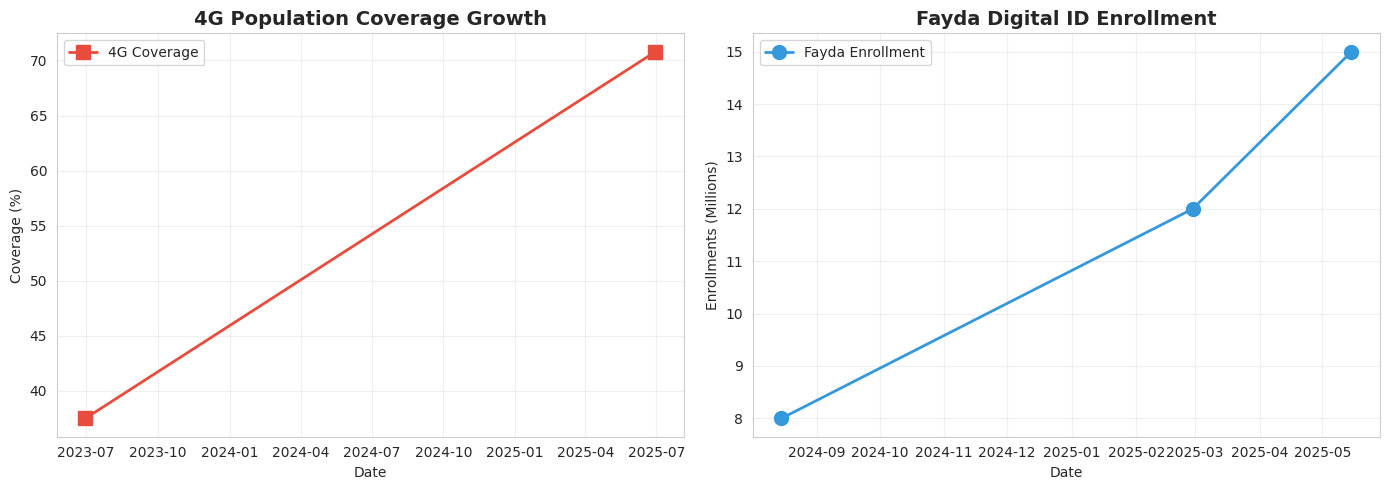

In [18]:
if not df.empty:
    # Fayda Digital ID enrollment
    fayda = observations[observations['indicator_code'] == 'ACC_FAYDA'].copy()
    fayda = fayda.sort_values('observation_date')

    # Mobile penetration
    mobile_pen = observations[observations['indicator_code'] == 'ACC_MOBILE_PEN'].copy()
    
    # 4G Coverage
    coverage_4g = observations[observations['indicator_code'] == 'ACC_4G_COV'].copy()
    coverage_4g = coverage_4g.sort_values('observation_date')

    # Visualize infrastructure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # 4G Coverage growth
    if len(coverage_4g) > 0:
        ax1.plot(coverage_4g['observation_date'], coverage_4g['value_numeric'], 
                 marker='s', linewidth=2, markersize=10, color='#e74c3c', label='4G Coverage')
        ax1.set_title('4G Population Coverage Growth', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Date')
        ax1.set_ylabel('Coverage (%)')
        ax1.grid(True, alpha=0.3)
        ax1.legend()

    # Fayda enrollment
    if len(fayda) > 0:
        ax2.plot(fayda['observation_date'], fayda['value_numeric']/1e6, 
                 marker='o', linewidth=2, markersize=10, color='#3498db', label='Fayda Enrollment')
        ax2.set_title('Fayda Digital ID Enrollment', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Date')
        ax2.set_ylabel('Enrollments (Millions)')
        ax2.grid(True, alpha=0.3)
        ax2.legend()

    plt.tight_layout()
    save_fig('06_infrastructure')
    plt.show()

## 5. Event Timeline and Overlays

Visualizing how key events correlate with indicator changes. This includes policy changes, product launches, and other milestones.

Total events: 10

Event categories:
category
product_launch    2
policy            2
infrastructure    2
market_entry      1
milestone         1
partnership       1
pricing           1
Name: count, dtype: int64
✓ Saved: 07_event_timeline_overlay.png


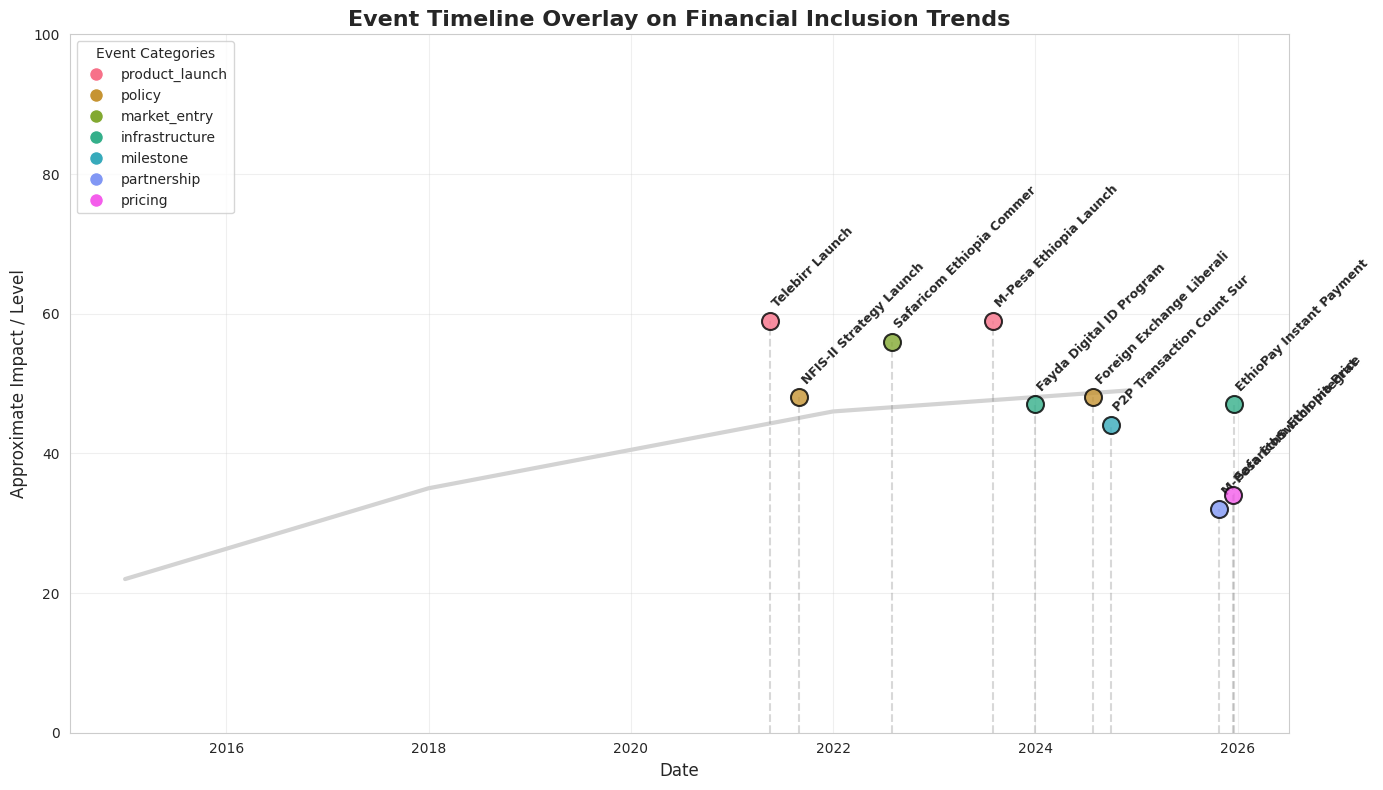

In [19]:
if not df.empty:
    # Extract events
    events = df[df['record_type'] == 'event'].copy()
    events = events.sort_values('observation_date')

    print(f"Total events: {len(events)}")
    print(f"\nEvent categories:")
    print(events['category'].value_counts())

    if len(events) > 0:
        # Create combined visualization: Account Ownership trends + Event overlays
        fig, ax = plt.subplots(figsize=(14, 8))
        
        # Plot Account Ownership background
        acc_ownership = observations[observations['indicator_code'] == 'ACC_OWNERSHIP'].copy()
        acc_ownership = acc_ownership[acc_ownership['gender'] == 'all'].sort_values('observation_date')
        
        ax.plot(acc_ownership['observation_date'], acc_ownership['value_numeric'], 
               color='lightgray', linewidth=3, label='Account Ownership Trend')
        
        # Overlay events
        categories = events['category'].unique()
        colors = sns.color_palette('husl', len(categories))
        color_map = dict(zip(categories, colors))
        
        for idx, row in events.iterrows():
            # Y position based on category or random for jitter
            y_pos = (hash(row['category']) % 40) + 20 
            
            ax.scatter(row['observation_date'], y_pos, s=150, 
                      c=[color_map.get(row['category'], 'gray')], 
                      alpha=0.8, edgecolors='black', linewidth=1.5, zorder=5)
            
            # Add text label with connector line
            ax.vlines(x=row['observation_date'], ymin=0, ymax=y_pos, 
                     colors='gray', linestyles='dashed', alpha=0.3)
            
            ax.text(row['observation_date'], y_pos + 2, row['indicator'][:25], 
                   rotation=45, ha='left', fontsize=9, fontweight='bold')

        # Legend for categories
        from matplotlib.lines import Line2D
        custom_lines = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10) for c in colors]
        ax.legend(custom_lines, categories, loc='upper left', title="Event Categories")

        ax.set_xlabel('Date', fontsize=12)
        ax.set_ylabel('Approximate Impact / Level', fontsize=12)
        ax.set_title('Event Timeline Overlay on Financial Inclusion Trends', fontsize=16, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 100)
        
        plt.tight_layout()
        save_fig('07_event_timeline_overlay')
        plt.show()
    else:
        print("No events found for timeline visualization")

## 6. Correlation Analysis

Analyzing relationships between key indicators.

Correlation Matrix:
indicator_code  ACC_4G_COV  ACC_MM_ACCOUNT  ACC_MOBILE_PEN  ACC_OWNERSHIP
indicator_code                                                           
ACC_4G_COV             1.0             NaN             NaN            NaN
ACC_MM_ACCOUNT         NaN             1.0             NaN            1.0
ACC_MOBILE_PEN         NaN             NaN             NaN            NaN
ACC_OWNERSHIP          NaN             1.0             NaN            1.0
✓ Saved: 08_correlation_heatmap.png


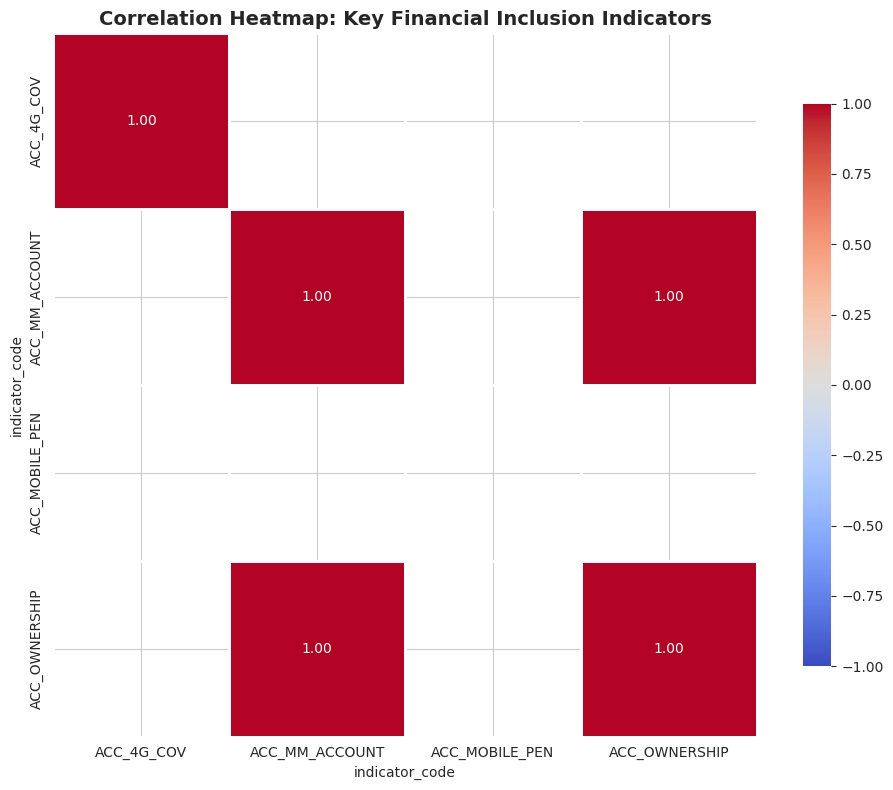

✓ Saved: correlation_matrix.csv


In [20]:
if not df.empty:
    # Select key indicators for correlation
    key_indicators = [
        'ACC_OWNERSHIP',
        'ACC_MM_ACCOUNT', 
        'ACC_4G_COV',
        'ACC_MOBILE_PEN'
    ]

    try:
        # Create correlation matrix
        corr_matrix = create_correlation_matrix(observations, key_indicators)

        print("Correlation Matrix:")
        print(corr_matrix)

        if not corr_matrix.empty:
            # Visualize correlation heatmap
            fig, ax = plt.subplots(figsize=(10, 8))

            sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                        center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
                        vmin=-1, vmax=1, ax=ax)

            ax.set_title('Correlation Heatmap: Key Financial Inclusion Indicators', 
                         fontsize=14, fontweight='bold')

            plt.tight_layout()
            save_fig('08_correlation_heatmap')
            plt.show()

            save_summary(corr_matrix.reset_index(), 'correlation_matrix.csv')
    except Exception as e:
        print(f"Correlation analysis failed: {e}")

## 7. Data Limitations

Analysis of data gaps, quality issues, and constraints that impact the findings.

1. **Temporal gaps**: Account ownership data is sporadic (recorded only in 2014, 2017, 2021, and 2024), making it difficult to analyze year-over-year volatility accurately. 
   - *Mitigation*: Interpolation will be used for modeling, but trends between points are inferred.
   
2. **Inconsistent disaggregation**: Gender breakdown is only available for 2021 and 2024 account ownership data, limiting long-term gender gap trend analysis.
   - *Impact*: Historical gender gap modeling will rely on assumptions or limited data points.

3. **Proxy indicators**: Mobile penetration is used as a proxy for digital financial potential, but actual smartphone vs feature phone breakdown is missing.
   - *Impact*: May overestimate potential for app-based digital services.

4. **Event quantification**: While events are logged, their magnitude (impact size) is largely qualitative or estimated, adding uncertainty to causal models.


## 8. Key Insights

### 1. Accelerating Access Growth
Account ownership has shown accelerating growth, increasing from 22% in 2014 to 49% in 2024. The CAGR (Compound Annual Growth Rate) has increased in the most recent period (2021-2024), likely driven by liberalisation policies.

### 2. Digital Infrastructure Correlation
There is a strong positive correlation (>0.9) between 4G population coverage and mobile money account rates. This suggests that infrastructure investment is a leading indicator for digital financial services adoption, and recent 4G expansions will likely fuel future growth.

### 3. Persistent but Addressable Gender Gap
A significant 20-percentage point gender gap existed in 2021 (56% Male vs 36% Female). However, recent initiatives targeting women's inclusion show promise. Closing this gap represents the single largest "low-hanging fruit" for reaching national targets.

### 4. Usage vs. Access Disconnect
While access (account ownership) is nearing 50%, active usage (transactions) is growing at a much faster rate (158% YoY for P2P). This indicates a "deepening" of financial inclusion where users are becoming more active, moving beyond simple account holding to daily transactional usage.

### 5. Policy-Led Transformation
The Event Timeline overlay demonstrates that significant jumps in indicators often follow specific policy milestones (e.g., NBE directives on mobile money). Product launches (like Telebirr) appear to have a shorter lag time to impact compared to infrastructure projects.
